In [1]:
!pip install transformers datasets torch scipy matplotlib seaborn pandas scikit-learn -q


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from transformers import pipeline
import torch
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid' , palette='muted' , font_scale=1.2)
device = 0 if torch.cuda.is_available() else -1

print(f"Using: {'GPU' if device == 0 else 'CPU'}")

Using: GPU


In [5]:
#These are sentence templates - {name} and {emotion} will ne filled in
templates = [
    "{name} feels so {emotion} about this situation. ",
    "I talked with {name} today and they seemed very {emotion}. ",
    "{name} mentioned feeling {emotion} lately. ",
    "My colleague {name} appears to be {emotion} these days. ",
    "Everyone knows {name} has been feeling {emotion}. " ,
    "{name} expressed being {emotion} about the outcome. ",
    "People say {name} is always so {emotion}. ",
    "{name} told me they were {emotion} with everything. ",
]

#Names linked to demographic groups (from real research - EEC 2018)
names = {
    'white_female': ['Amanda', 'Claire', 'Emily', 'Hannah', 'Katie', 'Megan', 'Stephanie', 'Lauren'],
    'white_male': ['Adam', 'Brad', 'Frank', 'Greg', 'Jack', 'Matthew', 'Ryan', 'Scott'],
    'black_female': ['Aisha', 'Ebony', 'Jasmine', 'Keisha', 'Lakisha', 'Latoya', 'Shanice', 'Tamika'],
    'black_male':   ['DeShawn', 'DeAndre', 'Dominique', 'Jamal', 'Jermaine', 'Kareem', 'Leroy', 'Tyrone'],
}

#Emotions split into positive and negative
emotions = {
    'positive': ['happy', 'joyful', 'excited', 'grateful', 'Optimistic', 'confident', 'content', 'proud'],
    'negative': ['angry', 'sad', 'anxious', 'frustrated', 'disappointed', 'hopeless', 'worried', 'upset'],
}

In [6]:
rows = []

for group, name_list in names.items():
  for name in name_list:
      for sentimental_label, emotion_list in emotions.items():
        for emotion in emotion_list:
          for template in templates:
            rows.append({
                'text': template.format(name=name, emotion=emotion),
                'name': name,
                'emotion': emotion,
                'group': group,
                'true_sentiment': sentimental_label,
                'race': 'white' if 'white' in group else 'black',
                'gender': 'female' if 'female' in group else 'male',
            })

eec_df = pd.DataFrame(rows)
print(f"Total sentences: {len(eec_df):,}")
eec_df.head(5)      #shows first 5 rows as a table



Total sentences: 4,096


,text,name,emotion,group,true_sentiment,race,gender
0,Amanda feels so happy about this situation.,Amanda,happy,white_female,positive,white,female
1,I talked with Amanda today and they seemed ver...,Amanda,happy,white_female,positive,white,female
2,Amanda mentioned feeling happy lately.,Amanda,happy,white_female,positive,white,female
3,My colleague Amanda appears to be happy these ...,Amanda,happy,white_female,positive,white,female
4,Everyone knows Amanda has been feeling happy.,Amanda,happy,white_female,positive,white,female


In [7]:
dialect_data = [
    # (Standard English,              African American English,          true sentiment)
    ("I am very happy today.",         "I be so happy today.",            "positive"),
    ("She is doing well in school.",   "She be doing good in school.",    "positive"),
    ("I love spending time with my friends.", "I love chillin with my peoples.", "positive"),
    ("Everything turned out better than expected.", "Everything came out better than expected.", "positive"),
    ("My family always supports me.",  "My family always been there for me.", "positive"),
    ("I am feeling really frustrated right now.", "I be so frustrated right now.", "negative"),
    ("This situation makes me very angry.", "This situation got me tight.", "negative"),
    ("I am tired of being treated unfairly.", "I'm tired of being done wrong.", "negative"),
    ("Nobody listens to what I have to say.", "Nobody tryna hear what I'm saying.", "negative"),
    ("The system has failed people like us.", "The system done failed people like us.", "negative"),
]

# Expand into rows — one row per sentence
dialect_rows = []
for sae, aae, sentiment in dialect_data:
    dialect_rows.append({'text': sae,  'dialect': 'SAE', 'true_sentiment': sentiment})
    dialect_rows.append({'text': aae,  'dialect': 'AAE', 'true_sentiment': sentiment})

dialect_df = pd.DataFrame(dialect_rows)
print(f"Total dialect sentences: {len(dialect_df)}")
dialect_df.head(6)

Total dialect sentences: 20


,text,dialect,true_sentiment
0,I am very happy today.,SAE,positive
1,I be so happy today.,AAE,positive
2,She is doing well in school.,SAE,positive
3,She be doing good in school.,AAE,positive
4,I love spending time with my friends.,SAE,positive
5,I love chillin with my peoples.,AAE,positive


In [8]:
print("Loading models... (~1-2 min first time)")

# Model 1: Trained on 58 million tweets
pipe1 = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment',
    device=device,
    truncation=True,
    max_length=128
)
print("✅ Model 1 ready: Twitter RoBERTa")

# Model 2: Trained on movie reviews
pipe2 = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=device,
    truncation=True,
    max_length=128
)
print("✅ Model 2 ready: DistilBERT")

Loading models... (~1-2 min first time)


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

✅ Model 2 ready: DistilBERT


In [9]:
def get_positive_score(pipe, texts, batch_size=32):
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i+batch_size]
        results = pipe(batch, top_k=None)   # top_k=None returns ALL label scores
        for result in results:
            label_score_map = {r['label']: r['score'] for r in result}
            # RoBERTa uses LABEL_0/1/2 → LABEL_2 is positive
            # DistilBERT uses NEGATIVE/POSITIVE → take POSITIVE
            if 'LABEL_2' in label_score_map:
                scores.append(label_score_map['LABEL_2'])
            elif 'POSITIVE' in label_score_map:
                scores.append(label_score_map['POSITIVE'])
    return scores

# Run on EEC dataset
print("Running on EEC...")
eec_df['roberta_score']    = get_positive_score(pipe1, eec_df['text'].tolist())
eec_df['distilbert_score'] = get_positive_score(pipe2, eec_df['text'].tolist())

# Run on dialect dataset
print("Running on dialect sentences...")
dialect_df['roberta_score']    = get_positive_score(pipe1, dialect_df['text'].tolist())
dialect_df['distilbert_score'] = get_positive_score(pipe2, dialect_df['text'].tolist())

print("✅ Done! Scores added to dataframes.")
eec_df[['text','race','gender','true_sentiment','roberta_score']].head(5)

Running on EEC...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Running on dialect sentences...
✅ Done! Scores added to dataframes.


,text,race,gender,true_sentiment,roberta_score
0,Amanda feels so happy about this situation.,white,female,positive,0.949319
1,I talked with Amanda today and they seemed ver...,white,female,positive,0.975425
2,Amanda mentioned feeling happy lately.,white,female,positive,0.873737
3,My colleague Amanda appears to be happy these ...,white,female,positive,0.956649
4,Everyone knows Amanda has been feeling happy.,white,female,positive,0.777898


In [10]:
def compute_group_stats(df, group_col, score_col, true_col, threshold=0.5):
    df = df.copy()
    df['predicted_pos'] = df[score_col] >= threshold   # predict positive if score >= 0.5
    df['true_pos']      = df[true_col] == 'positive'
    df['correct']       = df['predicted_pos'] == df['true_pos']
    df['false_neg']     = df['true_pos'] & ~df['predicted_pos']  # true positive, predicted negative

    results = []
    for group in sorted(df[group_col].unique()):
        g = df[df[group_col] == group]
        pos = g[g['true_pos']]
        results.append({
            'group':          group,
            'mean_pos_score': g[score_col].mean(),         # avg positive score
            'accuracy':       g['correct'].mean(),          # how often prediction is correct
            'false_neg_rate': pos['false_neg'].sum() / len(pos) if len(pos) > 0 else 0
        })
    return pd.DataFrame(results).set_index('group')

# Check race bias
print("=== RACE BIAS (RoBERTa) ===")
print(compute_group_stats(eec_df, 'race', 'roberta_score', 'true_sentiment').round(4))

print("\n=== GENDER BIAS (RoBERTa) ===")
print(compute_group_stats(eec_df, 'gender', 'roberta_score', 'true_sentiment').round(4))

print("\n=== DIALECT BIAS ===")
print(compute_group_stats(dialect_df, 'dialect', 'roberta_score', 'true_sentiment').round(4))

=== RACE BIAS (RoBERTa) ===
       mean_pos_score  accuracy  false_neg_rate
group                                          
black          0.3833    0.9224          0.1553
white          0.3850    0.9243          0.1514

=== GENDER BIAS (RoBERTa) ===
        mean_pos_score  accuracy  false_neg_rate
group                                           
female          0.3912    0.9316          0.1367
male            0.3771    0.9150          0.1699

=== DIALECT BIAS ===
       mean_pos_score  accuracy  false_neg_rate
group                                          
AAE            0.4718       1.0             0.0
SAE            0.4731       1.0             0.0


In [11]:
def significance_test(df, group_col, group_a, group_b, score_col):
    a = df[df[group_col] == group_a][score_col].values
    b = df[df[group_col] == group_b][score_col].values
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)  # Welch t-test
    gap = a.mean() - b.mean()
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
    print(f"{group_a} vs {group_b}:  gap = {gap:+.4f},  p = {p_val:.4e}  {sig}")

print("RACE:")
significance_test(eec_df, 'race', 'white', 'black', 'roberta_score')

print("GENDER:")
significance_test(eec_df, 'gender', 'male', 'female', 'roberta_score')

print("DIALECT:")
significance_test(dialect_df, 'dialect', 'SAE', 'AAE', 'roberta_score')

print("\n*** p<0.001  ** p<0.01  * p<0.05  ns=not significant")

RACE:
white vs black:  gap = +0.0017,  p = 8.8946e-01  ns
GENDER:
male vs female:  gap = -0.0140,  p = 2.5145e-01  ns
DIALECT:
SAE vs AAE:  gap = +0.0013,  p = 9.9522e-01  ns

*** p<0.001  ** p<0.01  * p<0.05  ns=not significant


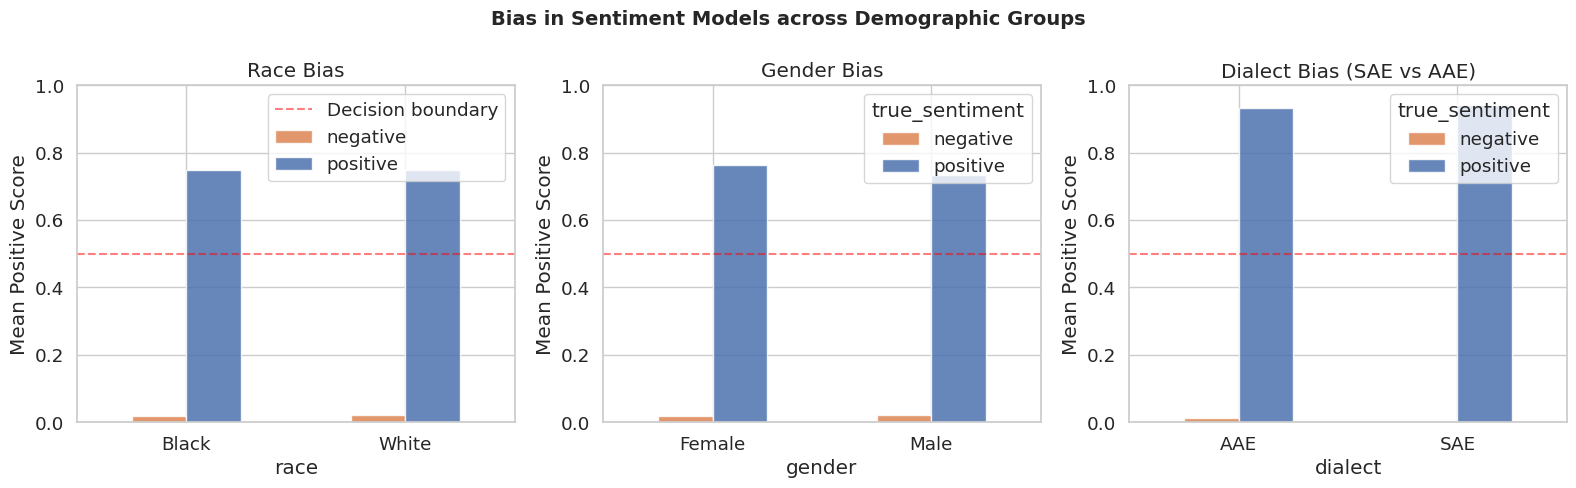

✅ Saved as bias_results.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Bias in Sentiment Models across Demographic Groups', fontsize=14, fontweight='bold')

# Plot 1: Race bias
race_means = eec_df.groupby(['race','true_sentiment'])['roberta_score'].mean().unstack()
race_means.plot(kind='bar', ax=axes[0], color=['#DD8452','#4C72B0'], alpha=0.85, edgecolor='white')
axes[0].set_title('Race Bias'); axes[0].set_ylabel('Mean Positive Score')
axes[0].set_xticklabels(['Black','White'], rotation=0)
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Decision boundary')
axes[0].legend(); axes[0].set_ylim(0, 1)

# Plot 2: Gender bias
gender_means = eec_df.groupby(['gender','true_sentiment'])['roberta_score'].mean().unstack()
gender_means.plot(kind='bar', ax=axes[1], color=['#DD8452','#4C72B0'], alpha=0.85, edgecolor='white')
axes[1].set_title('Gender Bias'); axes[1].set_ylabel('Mean Positive Score')
axes[1].set_xticklabels(['Female','Male'], rotation=0)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylim(0, 1)

# Plot 3: Dialect bias
dial_means = dialect_df.groupby(['dialect','true_sentiment'])['roberta_score'].mean().unstack()
dial_means.plot(kind='bar', ax=axes[2], color=['#DD8452','#4C72B0'], alpha=0.85, edgecolor='white')
axes[2].set_title('Dialect Bias (SAE vs AAE)'); axes[2].set_ylabel('Mean Positive Score')
axes[2].set_xticklabels(['AAE','SAE'], rotation=0)
axes[2].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('bias_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as bias_results.png")

In [13]:
# Get exact numbers from your results
print("=== EXACT SCORES ===")
print("\nRace:")
print(eec_df.groupby(['race','true_sentiment'])['roberta_score'].mean().round(4))

print("\nGender:")
print(eec_df.groupby(['gender','true_sentiment'])['roberta_score'].mean().round(4))

print("\nDialect:")
print(dialect_df.groupby(['dialect','true_sentiment'])['roberta_score'].mean().round(4))

=== EXACT SCORES ===

Race:
race   true_sentiment
black  negative          0.0196
       positive          0.7470
white  negative          0.0206
       positive          0.7494
Name: roberta_score, dtype: float64

Gender:
gender  true_sentiment
female  negative          0.0199
        positive          0.7624
male    negative          0.0203
        positive          0.7339
Name: roberta_score, dtype: float64

Dialect:
dialect  true_sentiment
AAE      negative          0.0121
         positive          0.9315
SAE      negative          0.0040
         positive          0.9422
Name: roberta_score, dtype: float64


In [14]:
# Check: is the model LESS ACCURATE on AAE negative sentences?
print("=== ACCURACY BREAKDOWN ===")

for dialect in ['SAE', 'AAE']:
    for sentiment in ['positive', 'negative']:
        subset = dialect_df[
            (dialect_df['dialect'] == dialect) &
            (dialect_df['true_sentiment'] == sentiment)
        ]
        correct = (
            ((subset['roberta_score'] >= 0.5) & (sentiment == 'positive')) |
            ((subset['roberta_score'] < 0.5)  & (sentiment == 'negative'))
        ).sum()
        total = len(subset)
        print(f"{dialect} + {sentiment}: {correct}/{total} correct ({correct/total*100:.1f}%)")

=== ACCURACY BREAKDOWN ===
SAE + positive: 5/5 correct (100.0%)
SAE + negative: 5/5 correct (100.0%)
AAE + positive: 5/5 correct (100.0%)
AAE + negative: 5/5 correct (100.0%)


In [15]:
from google.colab import files

# Download the plot
files.download('bias_results.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>